--- Resultados do K-means (Scikit-learn) ---
Para k = 3:
  Silhouette Score: 0.5526
  Tempo de execução: 0.0125 segundos

Para k = 5:
  Silhouette Score: 0.4885
  Tempo de execução: 0.0045 segundos

O melhor k encontrado foi 3 com um score de 0.5526.

--- Visualização dos Clusters com PCA (Sklearn) ---


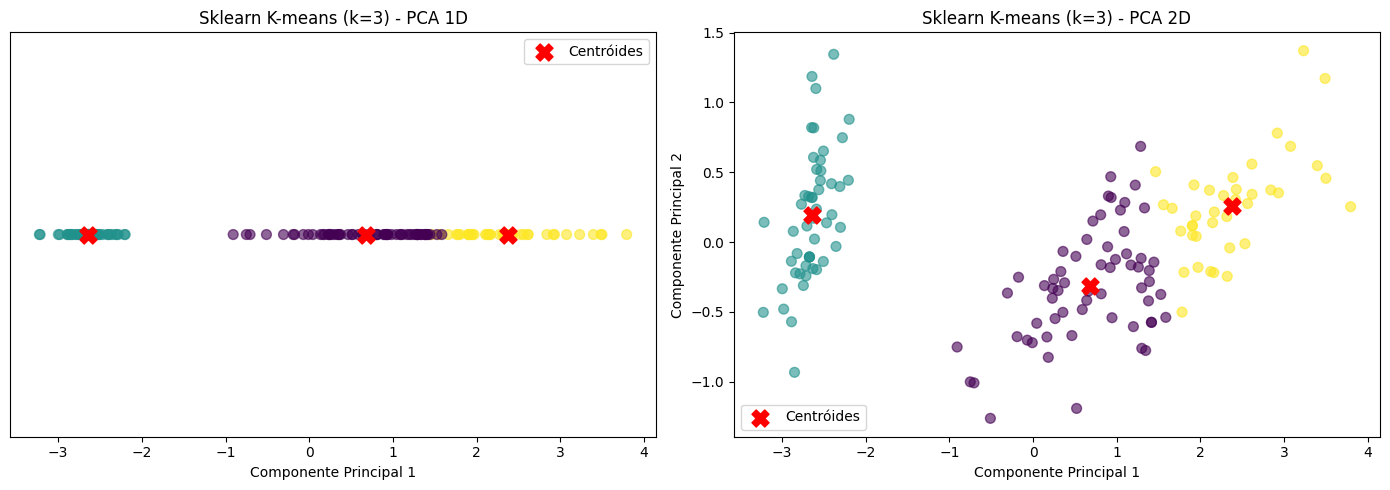

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Carregando e limpando os dados (igual ao hardcore)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=colunas)
X = df.drop('species', axis=1).values

# 2. Configurando o experimento
valores_k = [3, 5]

melhor_k_sklearn = 0
melhor_score_sklearn = -1
melhor_modelo_sklearn = None
melhores_clusters_sklearn = None

print("--- Resultados do K-means (Scikit-learn) ---")

for k in valores_k:
    inicio = time.time()
    
    # Instanciando e treinando o modelo pronto
    # n_init=10 e random_state=42 garantem estabilidade e reprodutibilidade nos resultados
    modelo_kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters = modelo_kmeans.fit_predict(X)
    
    fim = time.time()
    tempo_execucao = fim - inicio
    
    # Calculando a métrica
    score = silhouette_score(X, clusters)
    
    # Salvando o melhor resultado
    if score > melhor_score_sklearn:
        melhor_score_sklearn = score
        melhor_k_sklearn = k
        melhor_modelo_sklearn = modelo_kmeans
        melhores_clusters_sklearn = clusters
        
    print(f"Para k = {k}:")
    print(f"  Silhouette Score: {score:.4f}")
    print(f"  Tempo de execução: {tempo_execucao:.4f} segundos\n")

print(f"O melhor k encontrado foi {melhor_k_sklearn} com um score de {melhor_score_sklearn:.4f}.\n")

# 3. PCA e Plotagem Visual (Para comparação no relatório)
print("--- Visualização dos Clusters com PCA (Sklearn) ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# O Sklearn guarda os centróides no atributo 'cluster_centers_'
centroides_pca = pca.transform(melhor_modelo_sklearn.cluster_centers_)

plt.figure(figsize=(14, 5))

# --- Gráfico 1: PCA 1 Componente ---
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=melhores_clusters_sklearn, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centroides_pca[:, 0], np.zeros_like(centroides_pca[:, 0]), c='red', marker='X', s=150, label='Centróides')
plt.title(f'Sklearn K-means (k={melhor_k_sklearn}) - PCA 1D')
plt.xlabel('Componente Principal 1')
plt.yticks([])
plt.legend()

# --- Gráfico 2: PCA 2 Componentes ---
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=melhores_clusters_sklearn, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=150, label='Centróides')
plt.title(f'Sklearn K-means (k={melhor_k_sklearn}) - PCA 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()

plt.tight_layout()
plt.show()